**Two-factor Bergomi model**

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from data import get_xi0_interpolator, get_params, DATES
from two_bergomi import TwoFactorBergomiModel, get_params_two_factor_bergomi
from utils import non_uniform_grid, set_matplotlib_style

set_matplotlib_style()
SEED = 1234
SAVEFIG = False

# SSR Expansions

## Figure 2

Reproduces Figure 2 of the paper, which shows the SSR expansions for the two-factor 
Bergomi model with parameters from Bergomi (2016).

In [12]:
id = 2  # id = 1 or 2
params, xi0 = get_params_two_factor_bergomi(id)
n_quad = 40
two_bergomi = TwoFactorBergomiModel(params=params, xi0=xi0)

In [13]:
two_bergomi

TwoFactorBergomiModel with parameters:
w=3.48, k1=5.25, k2=0.28, theta=0.245, rho12=0.0, rhoS1=-0.35, rhoS2=-0.83, s0=1.0

In [14]:
# compute beta, atm skew and SSRs via BG expansion
Ts_bg = np.linspace(1e-3, 5, 200)
out_bg = two_bergomi.ssr_bg_all(Ts_bg, n_quad=n_quad)

In [15]:
Ts = non_uniform_grid(7 / 365, 5, 15, 1)
n_mc = 3 * 10**5
n_disc = 300
n_quad = 40
eps_ssr = 1e-3
out = two_bergomi.ssr_all(
    T=Ts,
    n_mc=n_mc,
    n_disc=n_disc,
    n_quad=n_quad,
    seed=SEED,
    eps_ssr=eps_ssr,
    conditioning=True,
    n_loop=6,
    n_batch=10,
)


Computing SSR:
----------------
Model: TwoFactorBergomiModel
Parameters:
Maturity T:  [0.01917808 0.35123288 0.68328767 1.01534247 1.34739726 1.67945205
 2.01150685 2.34356164 2.67561644 3.00767123 3.33972603 3.67178082
 4.00383562 4.33589041 4.66794521 5.        ]
Monte Carlo paths: 300000
Number of time steps: 300
Finite difference perturbation for SSR: 0.001
Number of simulation loops: 6
Number of independent batches: 10


Running batch 1/10 with seed 4206279609
1/16: expiry 0.0192
2/16: expiry 0.3512
3/16: expiry 0.6833
4/16: expiry 1.0153
5/16: expiry 1.3474
6/16: expiry 1.6795
7/16: expiry 2.0115
8/16: expiry 2.3436
9/16: expiry 2.6756
10/16: expiry 3.0077
11/16: expiry 3.3397
12/16: expiry 3.6718
13/16: expiry 4.0038
14/16: expiry 4.3359
15/16: expiry 4.6679
16/16: expiry 5.0000

Running batch 2/10 with seed 4194893554
1/16: expiry 0.0192
2/16: expiry 0.3512
3/16: expiry 0.6833
4/16: expiry 1.0153
5/16: expiry 1.3474
6/16: expiry 1.6795
7/16: expiry 2.0115
8/16: expiry 2.3436
9

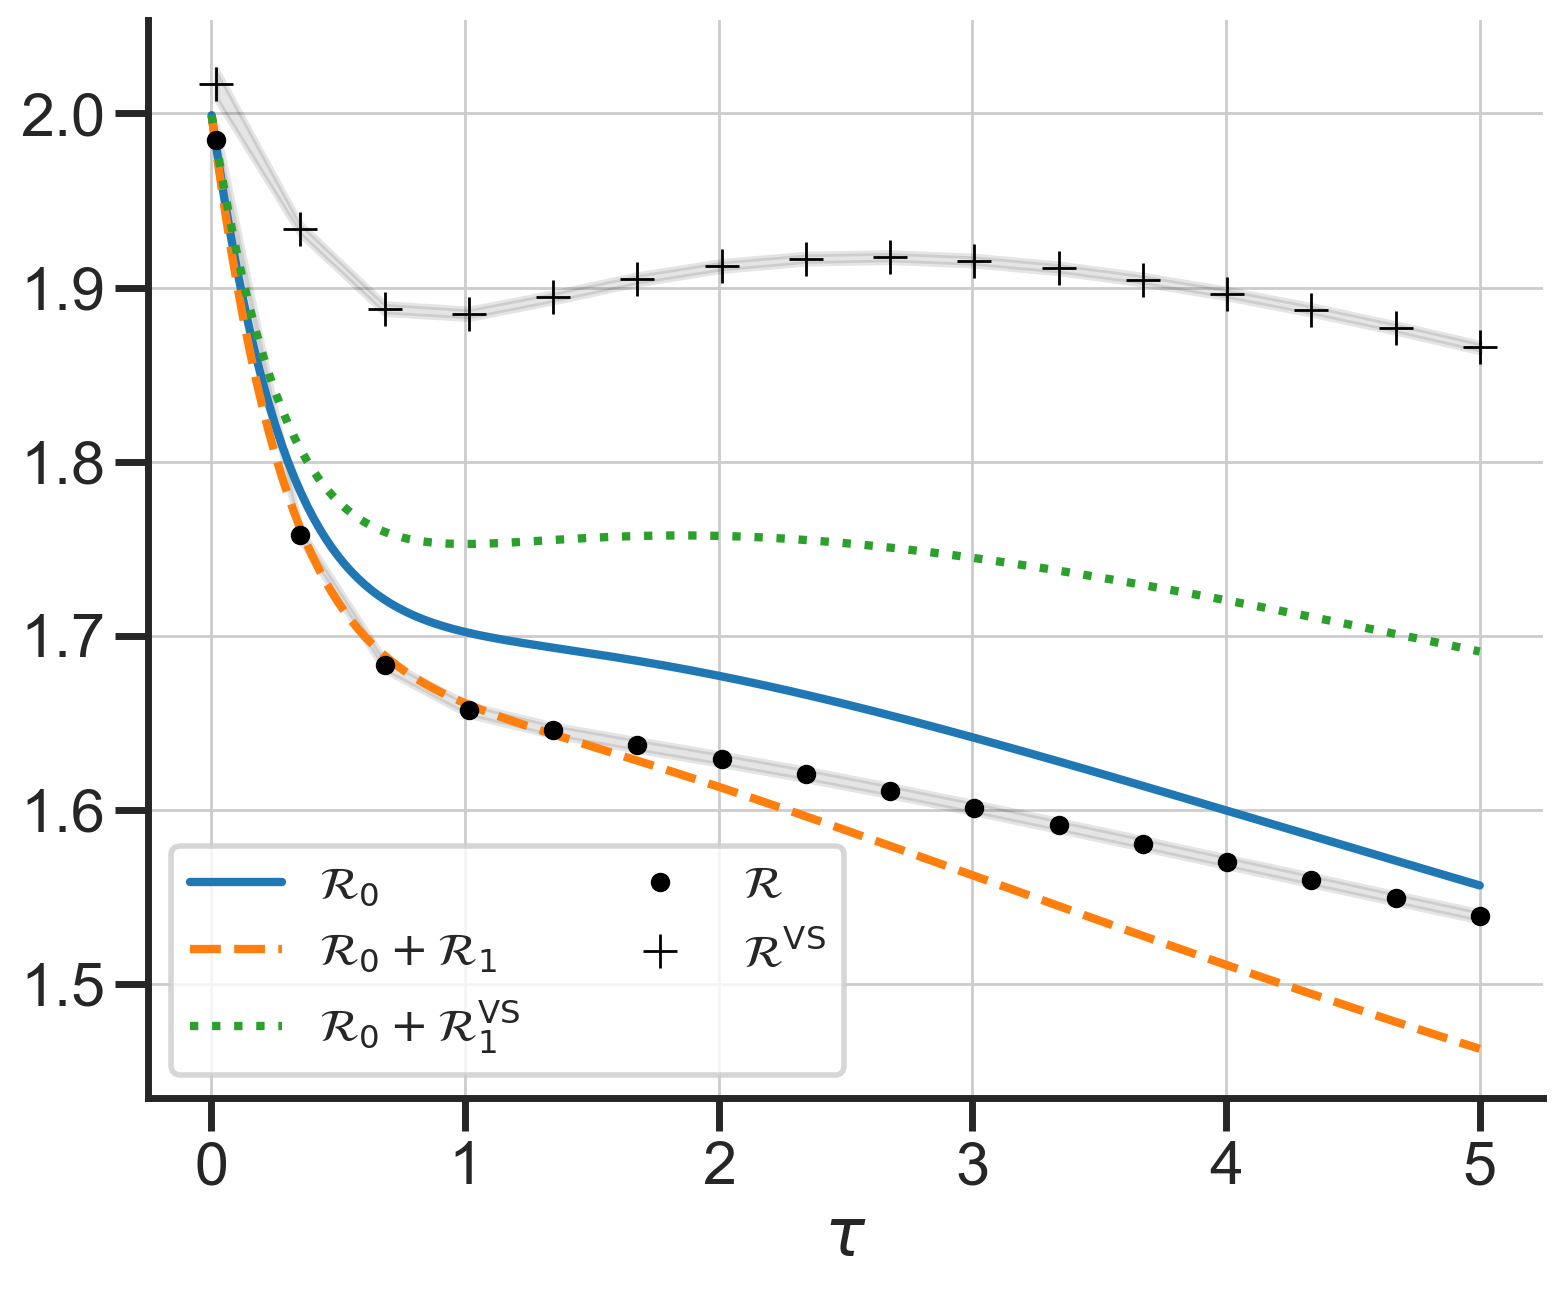

In [16]:
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["ssr_0"], "-", label=r"$\mathcal{R}_0$")
ax.plot(
    Ts_bg,
    out_bg["ssr_0"] + out_bg["ssr_1"],
    "--",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1$",
)
ax.plot(
    Ts_bg,
    out_bg["ssr_0"] + out_bg["ssr_vs_1"],
    ":",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1^{\text{VS}}$",
)
ax.plot(Ts, out["ssr_fd"], ".k", label=r"$\mathcal{R}$")
ax.fill_between(Ts, out["ssr_fd_low"], out["ssr_fd_high"], color="k", alpha=0.1)
ax.plot(Ts, out["ssr_vs"], "+k", label=r"$\mathcal{R}^{\text{VS}}$")
ax.fill_between(Ts, out["ssr_vs_low"], out["ssr_vs_high"], color="k", alpha=0.1)
# ax.plot([0], [2], "*k")
ax.legend(ncol=2)
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(
        f"figures/two_bergomi/two_bergomi_set_{id}_ssr.pdf", bbox_inches="tight"
    )
plt.show()

## Market data (Figure 7)

In [24]:
# parameters
date = DATES[1]
print(f"Using parameters from {date}")

model = "two_bergomi"
kind_interp = "cubic"
xi0 = get_xi0_interpolator(date, model, kind=kind_interp)
params = get_params(date=date, model=model)

# model
two_bergomi = TwoFactorBergomiModel(params=params, xi0=xi0)
two_bergomi

Using parameters from 2024-08-05


TwoFactorBergomiModel with parameters:
w=8.99, k1=14.56, k2=2.12, theta=0.32, rho12=-0.69, rhoS1=-0.47, rhoS2=-0.31, s0=1.0

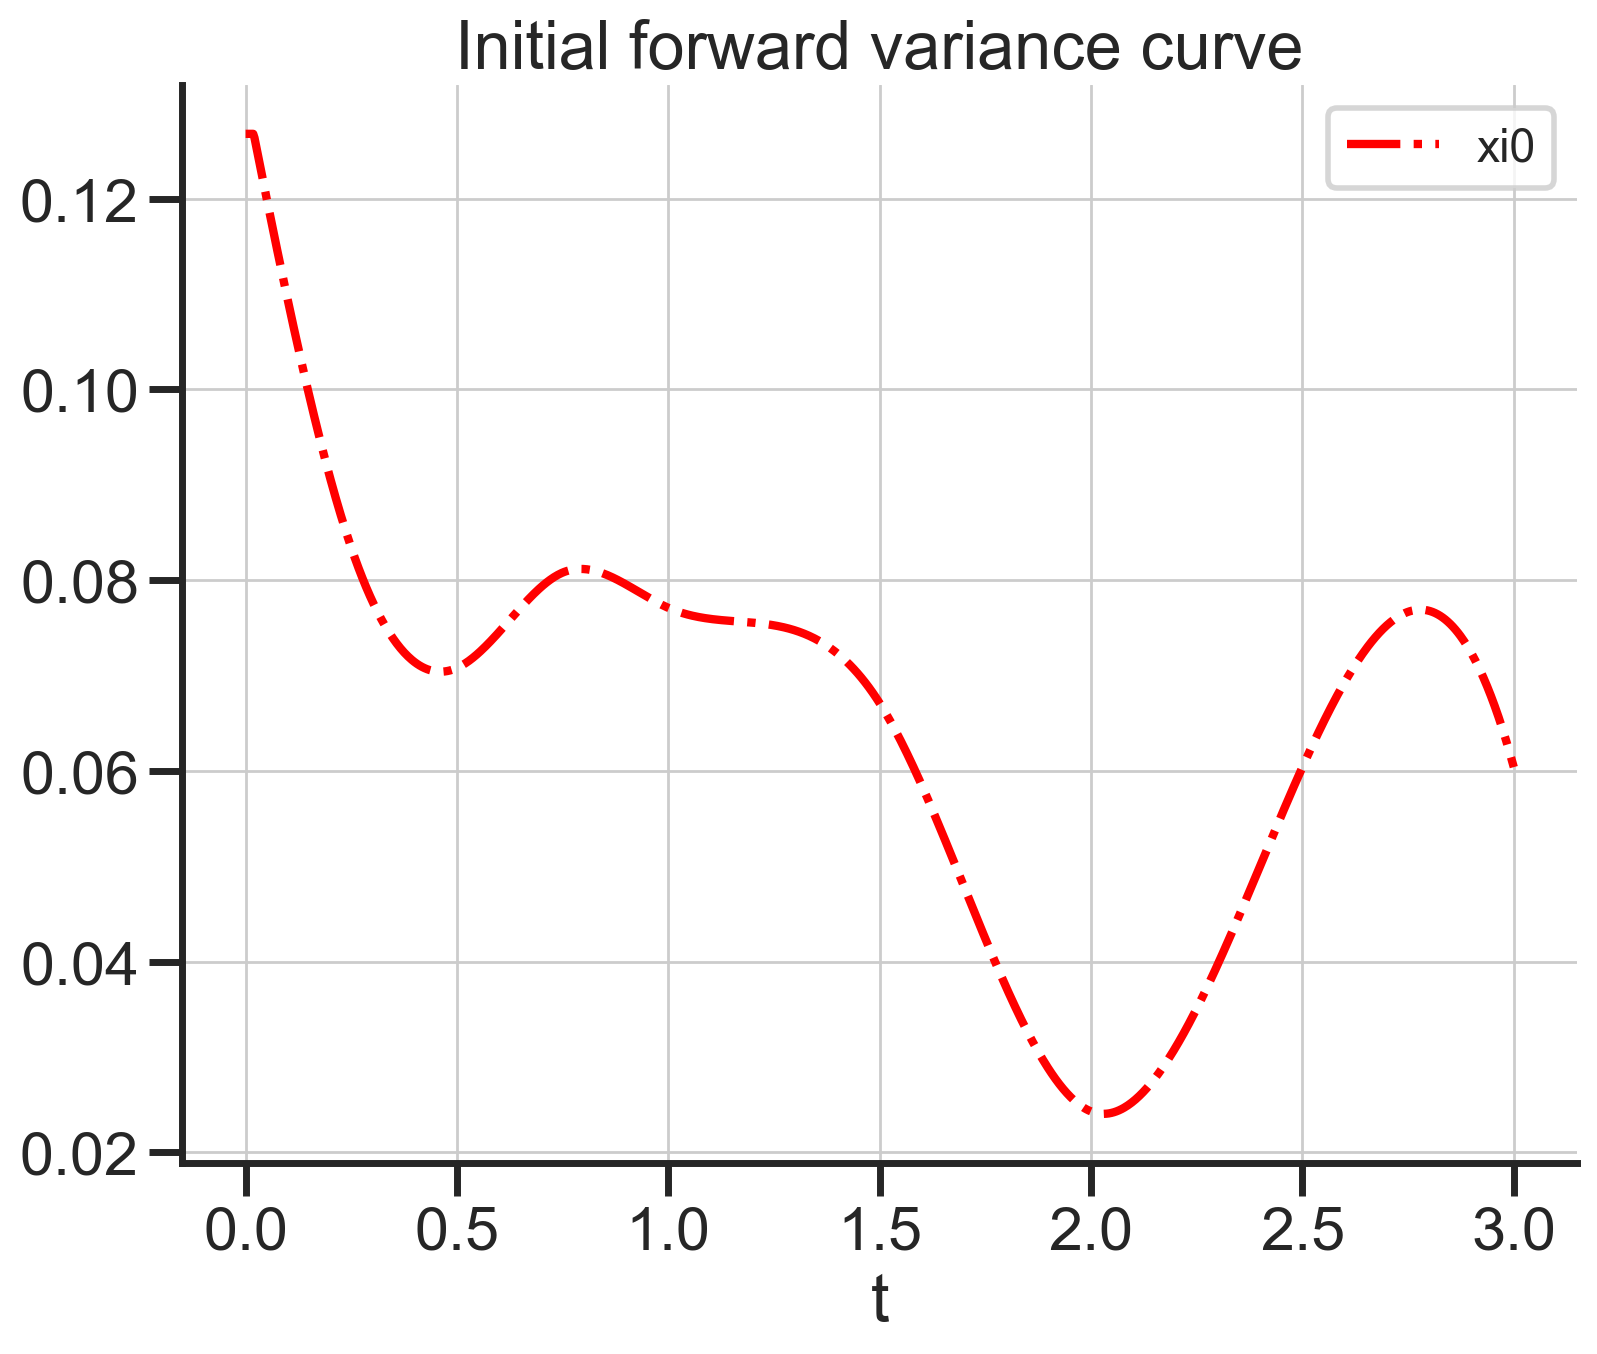

In [25]:
# plot xi0
us = np.linspace(0.0, 3.0, 1000)
fig, ax = plt.subplots()
ax.plot(us, xi0(us), "r-.", label="xi0")
ax.set_xlabel("t")
ax.set_title("Initial forward variance curve")
ax.legend()
plt.show()

In [ ]:
# compute true beta, atm skew and SSRs
Ts = non_uniform_grid(7 / 365, 3, 15, 1.5)
n_mc = 3 * 10**5
n_disc = 200
n_quad = 40
eps_ssr = 1e-3

out = two_bergomi.ssr_all(
    Ts,
    n_mc=n_mc,
    n_disc=n_disc,
    n_quad=n_quad,
    seed=SEED,
    eps_ssr=eps_ssr,
    conditioning=True,
    n_loop=1,
    n_batch=10,
)


Computing SSR:
----------------
Model: TwoFactorBergomiModel
Parameters:
Maturity T:  [0.01917808]
Monte Carlo paths: 300000
Number of time steps: 200
Finite difference perturbation for SSR: 0.001
Number of simulation loops: 1
Number of independent batches: 10


Running batch 1/10 with seed 4206279609
1/1: expiry 0.0192

Running batch 2/10 with seed 4194893554
1/1: expiry 0.0192

Running batch 3/10 with seed 4243172480
1/1: expiry 0.0192

Running batch 4/10 with seed 1632928246
1/1: expiry 0.0192

Running batch 5/10 with seed 735984819
1/1: expiry 0.0192

Running batch 6/10 with seed 3965312379
1/1: expiry 0.0192

Running batch 7/10 with seed 450510477
1/1: expiry 0.0192

Running batch 8/10 with seed 1123960401
1/1: expiry 0.0192

Running batch 9/10 with seed 596057731
1/1: expiry 0.0192

Running batch 10/10 with seed 1370511429
1/1: expiry 0.0192


In [37]:
# compute beta, atm skew and SSRs via BG expansion
Ts_bg = np.linspace(1e-3, 3, 200)
out_bg = two_bergomi.ssr_bg_all(Ts_bg, n_quad=n_quad)

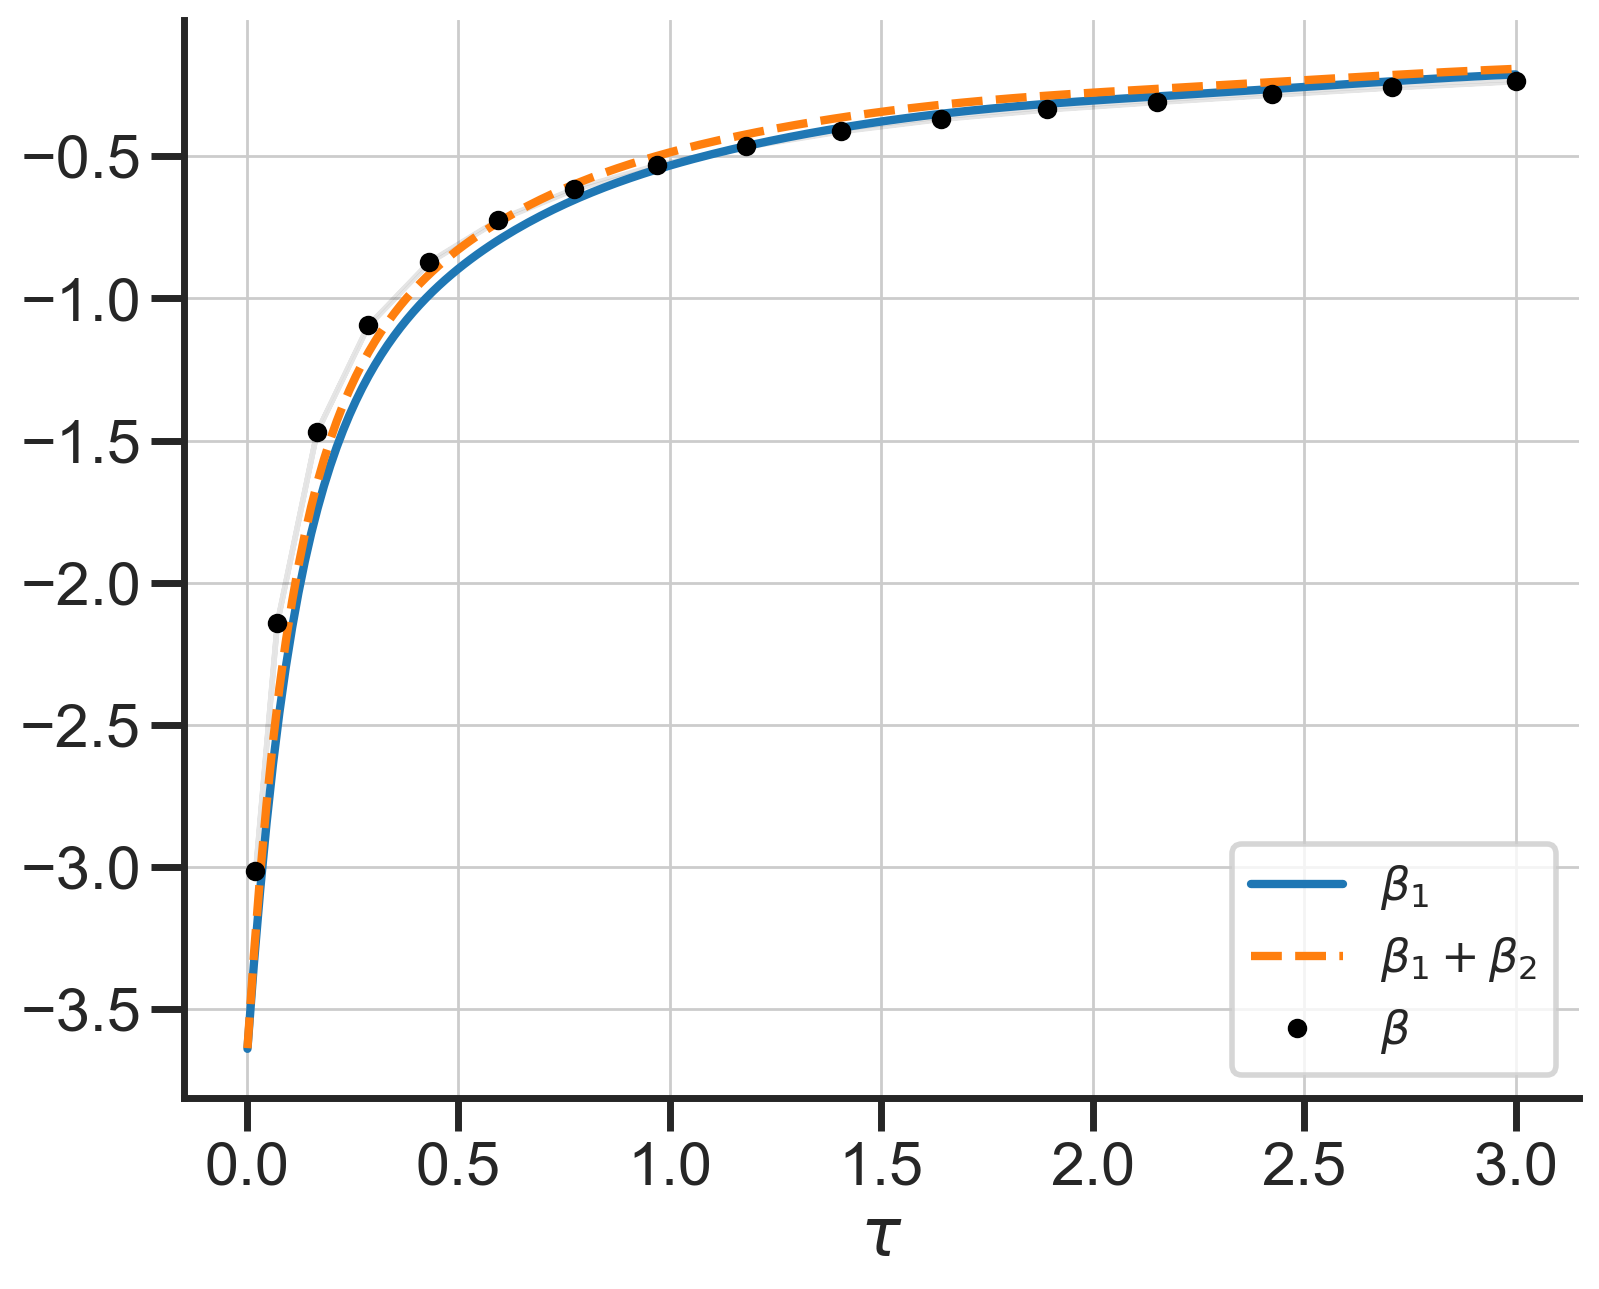

In [38]:
# plot beta
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["beta_1"], "-", label=r"$\beta_1$")
ax.plot(Ts_bg, out_bg["beta_1"] + out_bg["beta_2"], "--", label=r"$\beta_1+\beta_2$")
ax.plot(Ts, out["beta"], ".k", label=r"$\beta$")
ax.fill_between(Ts, out["beta_low"], out["beta_high"], color="k", alpha=0.1)
ax.legend()
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(f"figures/two_bergomi/two_bergomi_{date}_beta.pdf", bbox_inches="tight")
plt.show()

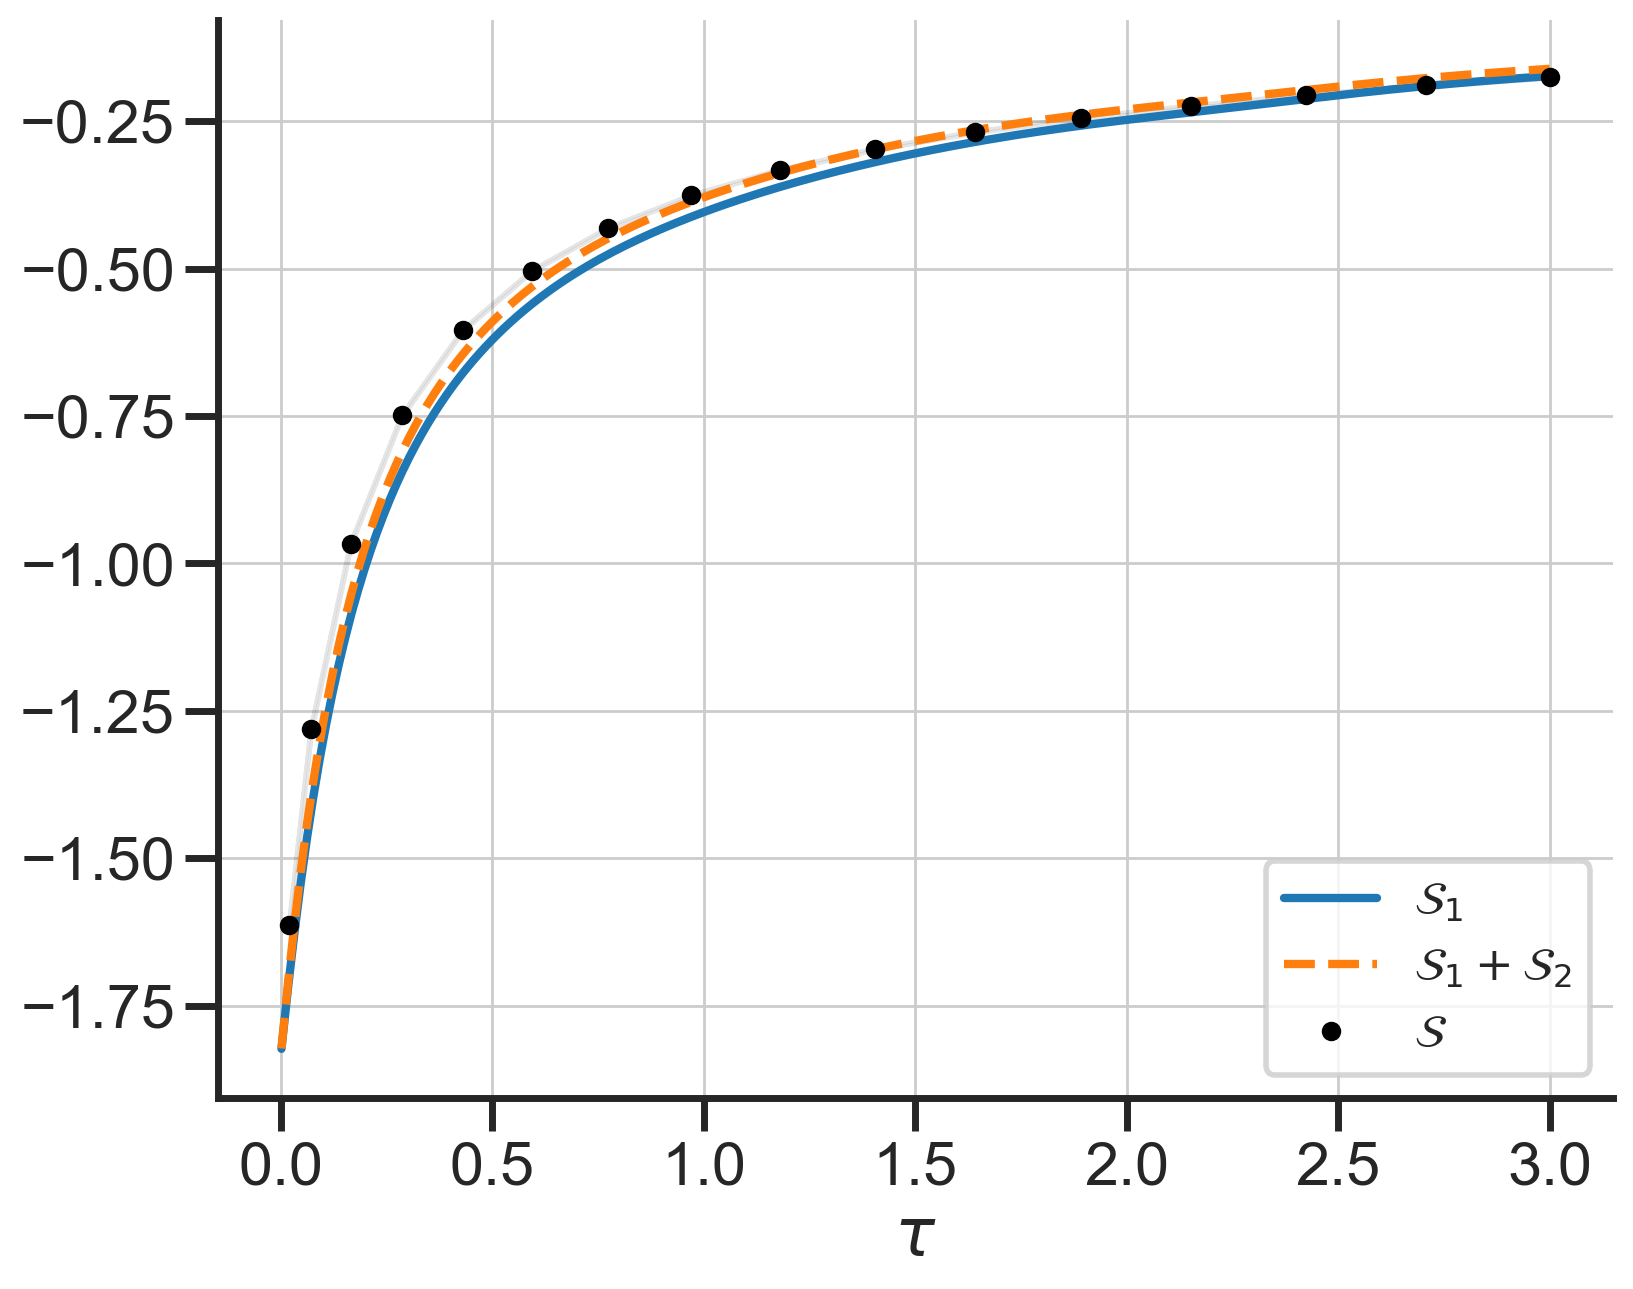

In [39]:
# plot ATM skew
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["atm_skew_1"], "-", label=r"$\mathcal{S}_1$")
ax.plot(
    Ts_bg,
    out_bg["atm_skew_1"] + out_bg["atm_skew_2"],
    "--",
    label=r"$\mathcal{S}_1+\mathcal{S}_2$",
)
ax.plot(Ts, out["atm_skew"], ".k", label=r"$\mathcal{S}$")
ax.fill_between(Ts, out["atm_skew_low"], out["atm_skew_high"], color="k", alpha=0.1)
ax.legend()
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(
        f"figures/two_bergomi/two_bergomi_{date}_atm_skew.pdf", bbox_inches="tight"
    )
plt.show()

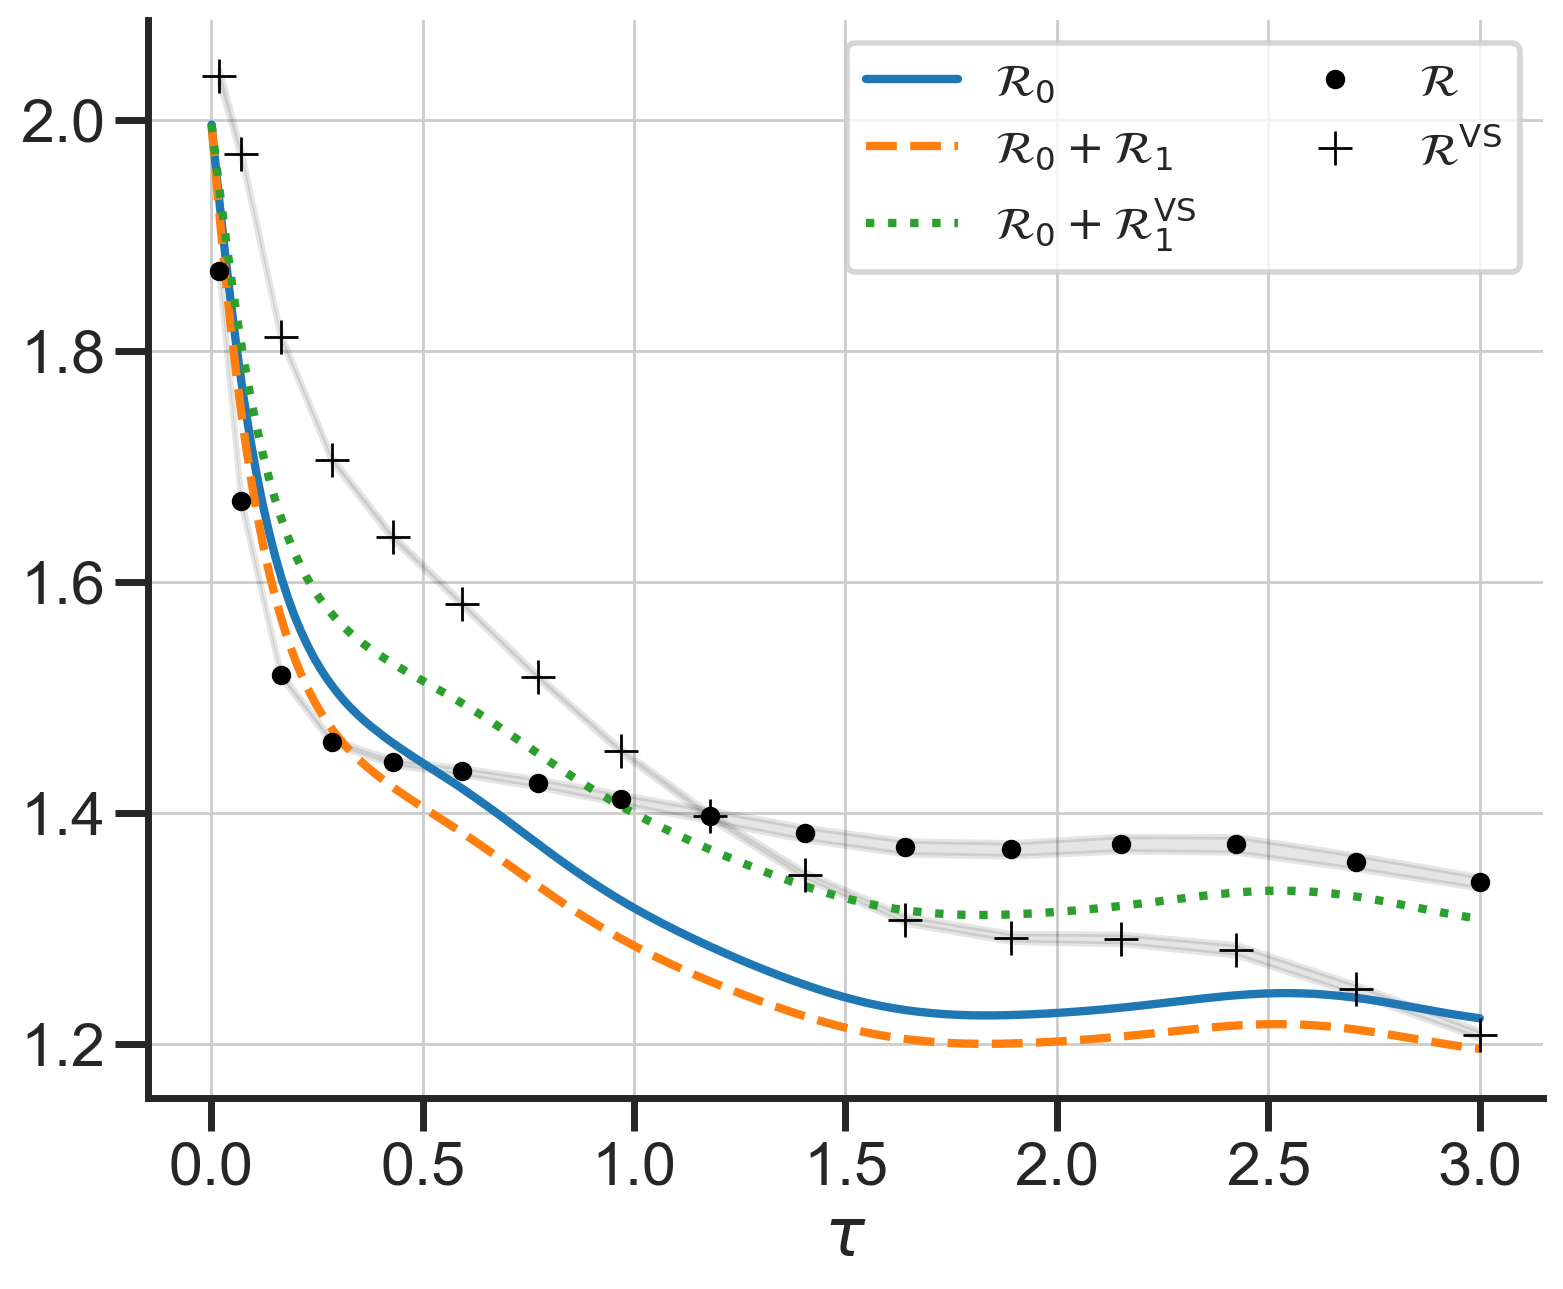

In [40]:
# plot SSR and VS SSR
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["ssr_0"], "-", label=r"$\mathcal{R}_0$")
ax.plot(
    Ts_bg,
    out_bg["ssr_0"] + out_bg["ssr_1"],
    "--",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1$",
)
ax.plot(
    Ts_bg,
    out_bg["ssr_0"] + out_bg["ssr_vs_1"],
    ":",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1^{\text{VS}}$",
)
ax.plot(Ts, out["ssr_fd"], ".k", label=r"$\mathcal{R}$")
ax.fill_between(Ts, out["ssr_fd_low"], out["ssr_fd_high"], color="k", alpha=0.1)
ax.plot(Ts, out["ssr_vs"], "+k", label=r"$\mathcal{R}^{\text{VS}}$")
ax.fill_between(Ts, out["ssr_vs_low"], out["ssr_vs_high"], color="k", alpha=0.1)
ax.legend(ncol=2)
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(f"figures/two_bergomi/two_bergomi_{date}_ssr.pdf", bbox_inches="tight")
plt.show()